# Video Action Recognition with TimeSformer

This notebook evaluates Facebook's **TimeSformer** on multiple labeled videos instead of a single demonstration video.

The model is `facebook/timesformer-base-finetuned-k400`, a TimeSformer checkpoint fine-tuned on the 400 Kinetics-400 action classes.

**Goal:**
To evaluate how a Kinetics-400 TimeSformer model behaves across multiple videos and temporal clips, while measuring classification accuracy, top-5 accuracy, confidence, prediction consistency, and inference time.

The evaluation uses a small labeled subset of UCF101 containing action classes that have direct semantic counterparts in Kinetics-400. This is a controlled cross-dataset evaluation, not a Kinetics-400 benchmark.


## Setup

We use the UCF101 subset published on Hugging Face. The subset contains labeled video examples and is small enough to run in Google Colab without downloading the full UCF101 dataset.

The TimeSformer checkpoint remains the same for every video and every clip.


In [ ]:
!pip install -q av transformers torch numpy matplotlib pandas scikit-learn huggingface_hub

In [ ]:
import os
import tarfile
import time
import shutil
from pathlib import Path

import av
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from huggingface_hub import hf_hub_download
from transformers import AutoImageProcessor, TimesformerForVideoClassification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_recall_fscore_support

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

np.random.seed(0)
torch.manual_seed(0)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(0)
model_id = "facebook/timesformer-base-finetuned-k400"

In [ ]:
dataset_id = "sayakpaul/ucf101-subset"
dataset_file = "UCF101_subset.tar.gz"

cached_dataset = hf_hub_download(
    repo_id=dataset_id,
    filename=dataset_file,
    repo_type="dataset"
)

extract_dir = Path("/content/UCF101_subset")

if extract_dir.exists():
    shutil.rmtree(extract_dir)

extract_dir.mkdir(parents=True, exist_ok=True)
with tarfile.open(cached_dataset, "r:*") as t:
    t.extractall(extract_dir)

print(f"Dataset ready: {extract_dir}")
print(list(extract_dir.iterdir()))

## Evaluation Classes

The UCF101 subset contains 10 action classes. We select the validation split so that the videos are not used for training the model.

The UCF101 labels are mapped to the corresponding Kinetics-400 label names used by TimeSformer. The mapping is semantic, so this should be interpreted as a cross-dataset evaluation rather than a standard Kinetics-400 test result.


In [ ]:
label_map = {
    "ApplyEyeMakeup": "applying eye makeup",
    "ApplyLipstick": "applying lipstick",
    "Archery": "archery",
    "BabyCrawling": "crawling baby",
    "BalanceBeam": "balance beam",
    "BandMarching": "marching",
    "BaseballPitch": "throwing ball",
    "Basketball": "playing basketball",
    "BasketballDunk": "dunking basketball",
    "BenchPress": "bench pressing"
}

data_root = extract_dir / "UCF101_subset"

if not data_root.exists():
    data_root = extract_dir

video_files = []

for class_name in label_map:
    class_dirs = [p for p in extract_dir.rglob(class_name) if "val" in p.parts]

    if len(class_dirs) == 0:
        class_dirs = list(extract_dir.rglob(class_name))  # fallback if no val split found

    if len(class_dirs) == 0:
        continue

    class_dir = class_dirs[0]

    for video_path in sorted(class_dir.glob("*.avi")):
        video_files.append({
            "path": str(video_path),
            "class": class_name,
            "kinetics_label": label_map[class_name]
        })

df = pd.DataFrame(video_files)

print(f"Total labeled videos found: {len(df)}")
print(df["class"].value_counts().sort_index())

## Build a Fixed Evaluation Subset

We use up to 3 validation videos per class. The subset is selected deterministically and remains fixed for all experiments.

Using multiple videos per class reduces the chance that the result is dominated by one unusually easy or difficult clip.


In [ ]:
validation_candidates = []

for class_name in label_map:
    class_files = df[df["class"] == class_name].sort_values("path").head(3)
    validation_candidates.append(class_files)

eval_df = pd.concat(validation_candidates, ignore_index=True)

print(f"Evaluation videos: {len(eval_df)}")
print(eval_df["class"].value_counts().sort_index())

## Video Decoding

The model expects a fixed number of frames. We decode only the selected frame indices rather than loading the complete video into memory.

TimeSformer-base uses 8 input frames, so the same 8-frame input size is used for every clip.


In [ ]:
def read_video_pyav(container, indices):
    frames = []
    container.seek(0)

    start_index = int(indices[0])
    end_index = int(indices[-1])

    for i, frame in enumerate(container.decode(video=0)):
        if i > end_index:
            break
        if i >= start_index and i in indices:
            frames.append(frame)

    if len(frames) != len(indices):
        raise RuntimeError(f"Expected {len(indices)} frames but decoded {len(frames)}.")

    return np.stack([x.to_ndarray(format="rgb24") for x in frames])

def get_total_frames(video_path):
    container = av.open(video_path)
    total_frames = sum(1 for _ in container.decode(video=0))
    container.close()
    return int(total_frames)

def sample_uniform_indices(clip_len, seg_len):
    if seg_len < clip_len:
        raise ValueError(f"Video has only {seg_len} frames.")

    indices = np.linspace(0, seg_len - 1, num=clip_len)
    return indices.astype(np.int64)


def sample_random_indices(clip_len, seg_len):
    if seg_len < clip_len:
        raise ValueError(f"Video has only {seg_len} frames.")

    start_idx = np.random.randint(0, seg_len - clip_len + 1)
    return np.arange(start_idx, start_idx + clip_len, dtype=np.int64)

## Load TimeSformer

The checkpoint is loaded once and used for all videos.

The model predicts one of the 400 Kinetics-400 classes. Because the evaluation videos come from UCF101, only the selected overlapping semantic classes are used as ground truth.


In [ ]:
image_processor = AutoImageProcessor.from_pretrained(model_id)
model = TimesformerForVideoClassification.from_pretrained(model_id).to(device)
model.eval()

print(f"Model loaded on: {device}")
print(f"Number of model labels: {model.config.num_labels}")
print(f"Expected input frames: {model.config.num_frames}")

## Run One Video

For each video we evaluate both a deterministic uniform clip and several randomly sampled temporal clips.

The uniform clip gives a fixed reproducible result. The repeated random clips test whether the prediction is stable when the temporal location of the sampled frames changes.


In [ ]:
def predict_clip(video_path, indices):
    container = av.open(video_path)
    video_frames = read_video_pyav(container, indices)
    container.close()

    inputs = image_processor(list(video_frames), return_tensors="pt").to(device)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start_time = time.perf_counter()

    with torch.no_grad():
        outputs = model(**inputs)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    inference_time = time.perf_counter() - start_time

    probs = torch.nn.functional.softmax(outputs.logits, dim=-1)[0]
    top5_probs, top5_indices = torch.topk(probs, k=5)

    top5_labels = [model.config.id2label[int(i)] for i in top5_indices]
    top5_probs = top5_probs.cpu().numpy()

    return {
        "frames": video_frames,
        "indices": indices,
        "top1_label": top5_labels[0],
        "top1_confidence": float(top5_probs[0]),
        "top5_labels": top5_labels,
        "top5_probs": top5_probs,
        "time": inference_time
    }

## Multi-Video Evaluation

Each video gets one uniform clip and three random clips.

Top-1 and top-5 accuracy are calculated using the known UCF101 label mapped to its corresponding Kinetics-400 class. The random clips are not treated as independent videos; they are used to measure temporal prediction stability.


In [ ]:
results = []

for _, row in eval_df.iterrows():
    video_path = row["path"]
    true_label = row["kinetics_label"]

    total_frames = get_total_frames(video_path)

    uniform_indices = sample_uniform_indices(model.config.num_frames, total_frames)
    uniform_result = predict_clip(video_path, uniform_indices)

    results.append({
        "video": Path(video_path).name,
        "class": row["class"],
        "true_label": true_label,
        "sampling": "uniform",
        "clip": 0,
        "prediction": uniform_result["top1_label"],
        "confidence": uniform_result["top1_confidence"],
        "top5_labels": uniform_result["top5_labels"],
        "time": uniform_result["time"]
    })

    for clip_id in range(1, 4):
        random_indices = sample_random_indices(model.config.num_frames, total_frames)
        random_result = predict_clip(video_path, random_indices)

        results.append({
            "video": Path(video_path).name,
            "class": row.get("class") if hasattr(row, "get") else row["class"],
            "true_label": true_label,
            "sampling": "random",
            "clip": clip_id,
            "prediction": random_result["top1_label"],
            "confidence": random_result["top1_confidence"],
            "top5_labels": random_result["top5_labels"],
            "time": random_result["time"]
        })

results_df = pd.DataFrame(results)

print(f"Total evaluated clips: {len(results_df)}")
display(results_df.head())

## Classification Metrics

The primary accuracy calculation uses the uniform clip from each video so that every video contributes exactly once.

Top-1 accuracy measures whether the predicted class is correct. Top-5 accuracy measures whether the reference class appears anywhere in the five highest-scoring predictions.

Precision, recall, and F1 are also reported as macro averages across the evaluated classes.


In [ ]:
uniform_df = results_df[results_df["sampling"] == "uniform"].copy()

uniform_df["top1_correct"] = uniform_df["prediction"] == uniform_df["true_label"]

uniform_df["top5_correct"] = uniform_df.apply(
    lambda row: row["true_label"] in row["top5_labels"],
    axis=1
)

top1_accuracy = uniform_df["top1_correct"].mean()
top5_accuracy = uniform_df["top5_correct"].mean()

precision, recall, f1, _ = precision_recall_fscore_support(
    uniform_df["true_label"],
    uniform_df["prediction"],
    average="macro",
    zero_division=0
)

print(f"Top-1 Accuracy: {top1_accuracy:.4f}")
print(f"Top-5 Accuracy: {top5_accuracy:.4f}")
print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall: {recall:.4f}")
print(f"Macro F1: {f1:.4f}")

## Confusion Matrix

The confusion matrix shows which evaluated action classes are confused with each other.

Because this is a small cross-dataset subset, the matrix should be interpreted as an error analysis tool rather than as a general estimate of Kinetics-400 performance.


In [ ]:
labels = sorted(uniform_df["true_label"].unique())

cm = confusion_matrix(
    uniform_df["true_label"],
    uniform_df["prediction"],
    labels=labels
)

plt.figure(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(xticks_rotation=45, cmap="Blues", values_format="d")
plt.title("TimeSformer Confusion Matrix")
plt.tight_layout()
plt.show()

## Temporal Prediction Consistency

The same video is sampled at different temporal locations. If the model predicts the same top-1 action across the uniform clip and random clips, the prediction is temporally consistent.

This metric does not measure correctness. A model can be consistently wrong, so consistency is reported separately from accuracy.


In [ ]:
consistency_rows = []

for video_name, group in results_df.groupby("video"):
    predictions = group["prediction"].tolist()
    majority_prediction = group["prediction"].value_counts().index[0]
    majority_fraction = group["prediction"].value_counts().iloc[0] / len(predictions)

    consistency_rows.append({
        "video": video_name,
        "majority_prediction": majority_prediction,
        "consistency": majority_fraction,
        "mean_confidence": group["confidence"].mean()
    })

consistency_df = pd.DataFrame(consistency_rows)

print(f"Mean temporal consistency: {consistency_df['consistency'].mean():.4f}")
print(f"Mean confidence: {consistency_df['mean_confidence'].mean():.4f}")

display(consistency_df.head())

## Inference Time

Inference time is measured for the same 8-frame input size across all clips.

GPU synchronization is used when CUDA is available so that asynchronous GPU execution does not make the measured forward-pass time artificially small.


In [ ]:
mean_time = results_df["time"].mean()
median_time = results_df["time"].median()

print(f"Mean inference time: {mean_time:.4f} seconds")
print(f"Median inference time: {median_time:.4f} seconds")
print(f"Clips per second: {1 / mean_time:.2f}")

## Example Video and Temporal Samples

The following visualization shows the frames used for one uniform clip.

The model's prediction is displayed with the reference label. This gives a visual check of the temporal input used by the classifier.


In [ ]:
example_row = eval_df.iloc[0]

example_total_frames = get_total_frames(example_row["path"])
example_indices = sample_uniform_indices(model.config.num_frames, example_total_frames)
example_result = predict_clip(example_row["path"], example_indices)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

fig.suptitle(
    f"TimeSformer Input: 8 Uniformly Sampled Frames\n"
    f"True: {example_row['kinetics_label']} | "
    f"Predicted: {example_result['top1_label']} "
    f"({example_result['top1_confidence']:.2%})",
    fontsize=14
)

for i, ax in enumerate(axes.flat):
    ax.imshow(example_result["frames"][i])
    ax.set_title(f"Frame {example_indices[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Final Quantitative Summary

The final table separates classification quality, confidence, temporal consistency, and computational cost.

These quantities answer different questions. Accuracy measures correctness, confidence measures the model's probability output, consistency measures sensitivity to temporal sampling, and inference time measures computational cost.


In [ ]:
summary = pd.DataFrame([{
    "Top-1 Accuracy": top1_accuracy,
    "Top-5 Accuracy": top5_accuracy,
    "Macro Precision": precision,
    "Macro Recall": recall,
    "Macro F1": f1,
    "Mean Confidence": uniform_df["confidence"].mean(),
    "Temporal Consistency": consistency_df["consistency"].mean(),
    "Mean Inference Time (s)": mean_time,
    "Median Inference Time (s)": median_time,
    "Clips/sec": 1 / mean_time
}])

display(summary.round(4))

In [ ]:
metric_names = [
    "Top-1 Accuracy",
    "Top-5 Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "Temporal Consistency"
]

metric_values = [
    top1_accuracy,
    top5_accuracy,
    precision,
    recall,
    f1,
    consistency_df["consistency"].mean()
]

plt.figure(figsize=(11, 5))
plt.bar(metric_names, metric_values)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.title("TimeSformer Evaluation Metrics")
plt.tight_layout()
plt.show()

# Interpretation and Limitations

The TimeSformer model was evaluated on 30 videos and 120 clips, achieving 56.67% Top-1 accuracy and 66.67% Top-5 accuracy. This shows moderate action-recognition performance, with the correct class appearing in the top five predictions for about two-thirds of the samples.

The Macro F1 score of 32.22% indicates relatively uneven performance across different action classes, while the 84.17% temporal consistency shows that predictions remained stable across different temporal samples of the same videos. However, consistency does not necessarily mean the predictions were correct.

**Limitations:** The evaluation uses a small, selected UCF101 subset with semantic overlap with Kinetics-400, so the results should not be considered general benchmark performance. The limited number of videos also restricts how broadly the results can be generalized.

Overall, the experiment demonstrates moderate classification accuracy with strong temporal stability, while highlighting the need for a larger and more diverse evaluation dataset.

In [ ]:
print("Evaluation complete.")
print(f"Videos evaluated: {len(eval_df)}")
print(f"Clips evaluated: {len(results_df)}")
print(f"Top-1 accuracy: {top1_accuracy:.4f}")
print(f"Top-5 accuracy: {top5_accuracy:.4f}")
print(f"Macro F1: {f1:.4f}")
print(f"Temporal consistency: {consistency_df['consistency'].mean():.4f}")

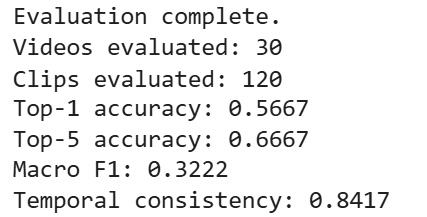